In [32]:
import pandas as pd

train_df = pd.read_csv('train.csv').drop(columns=['Id'])
train_df[label] = pd.to_numeric(train_df[label], errors='coerce')

test_df = pd.read_csv('test.csv').drop(columns=['Id'])

label = 'SalePrice'
if label in test_df.columns:
    test_df = test_df.drop(columns=[label])

In [ ]:
import ydf

# Train model with task specified as REGRESSION
model = ydf.GradientBoostedTreesLearner(
    label=label,
    task=ydf.Task.REGRESSION
).train(train_df)

Feature Utilities is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature PoolQC is a CATEGORICAL feature with an empty dictionary. The feature will not be useful during model training.
Feature MiscFeature is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Train model on 1460 examples
Model trained in 0:00:00.280152


In [34]:
evaluation = model.evaluate(train_df)
print(evaluation)

RMSE: 11726
num examples: 1460
num examples (weighted): 1460



In [ ]:
# Get predictions
train_predictions = model.predict(train_df)
test_predictions = model.predict(test_df)

# Get actual values
train_actual = train_df[label].values

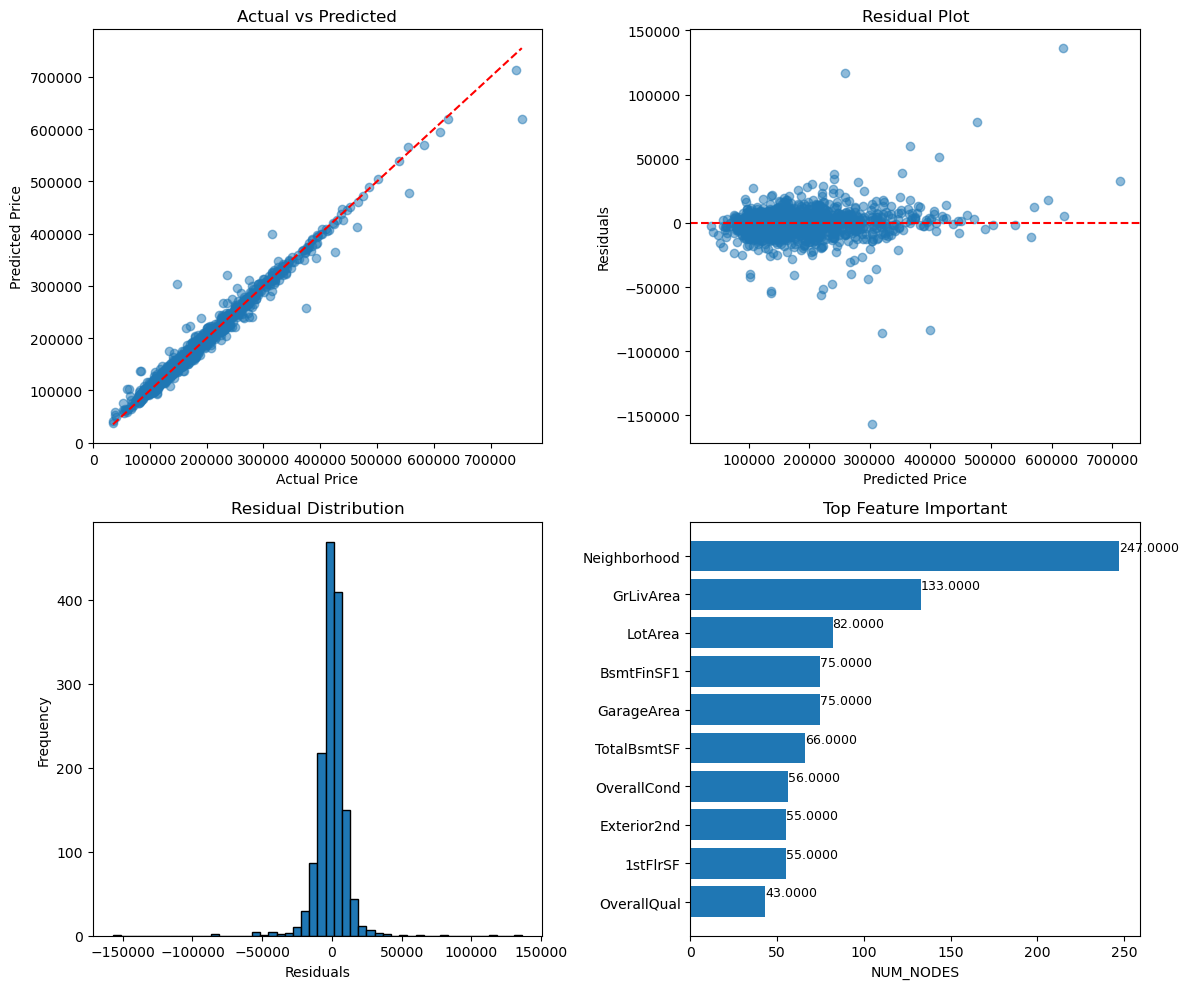

In [46]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(train_actual, train_predictions, alpha=0.5)
axes[0, 0].plot([train_actual.min(), train_actual.max()], 
                [train_actual.min(), train_actual.max()], 'r--')
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Actual vs Predicted')

# 2. Residuals
residuals = train_actual - train_predictions
axes[0, 1].scatter(train_predictions, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Price')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution')

# 4. Feature importance - Use NUM_NODES metric
variable_importance_metric = "NUM_NODES"
variable_importances = model.variable_importances()[variable_importance_metric]

# Extract the feature name and importance values
feature_names = [vi[1] for vi in variable_importances]  # Feature names are in position 1
feature_importances = [vi[0] for vi in variable_importances]  # Scores are in position 0

# Get top 10
feature_names = feature_names[:10]
feature_importances = feature_importances[:10]
feature_ranks = range(len(feature_names))

# Create horizontal bar chart
bars = axes[1, 1].barh(feature_ranks, feature_importances)
axes[1, 1].set_yticks(feature_ranks)
axes[1, 1].set_yticklabels(feature_names)
axes[1, 1].invert_yaxis()

# Add value labels on bars
for importance, patch in zip(feature_importances, bars.patches):
    axes[1, 1].text(patch.get_x() + patch.get_width(), patch.get_y(), 
                    f"{importance:.4f}", va="top", fontsize=9)

axes[1, 1].set_xlabel(variable_importance_metric)
axes[1, 1].set_title('Top Feature Important')

plt.tight_layout()
plt.show()

In [47]:
# Print prediction statistics
print("\n=== Prediction Statistics ===")
print(f"Train predictions - Mean: ${train_predictions.mean():,.2f}, Std: ${train_predictions.std():,.2f}")
print(f"Test predictions - Mean: ${test_predictions.mean():,.2f}, Std: ${test_predictions.std():,.2f}")

# Show first few test predictions
print("\n=== First 10 Test Predictions ===")
print(pd.DataFrame({
    'Index': range(len(test_predictions[:10])),
    'Predicted Price': [f"${p:,.2f}" for p in test_predictions[:10]]
}))

# Summary of test predictions
print(f"\nTest set: Min=${test_predictions.min():,.2f}, Max=${test_predictions.max():,.2f}")


=== Prediction Statistics ===
Train predictions - Mean: $181,084.86, Std: $77,228.66
Test predictions - Mean: $178,918.88, Std: $75,759.03

=== First 10 Test Predictions ===
   Index Predicted Price
0      0     $126,818.87
1      1     $158,173.66
2      2     $186,715.94
3      3     $186,409.98
4      4     $198,843.77
5      5     $177,358.42
6      6     $172,306.53
7      7     $169,009.81
8      8     $182,822.84
9      9     $126,770.42

Test set: Min=$37,974.95, Max=$543,586.62


In [48]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Calculate metrics on training set
r2 = r2_score(train_actual, train_predictions)
rmse = np.sqrt(mean_squared_error(train_actual, train_predictions))
mae = mean_absolute_error(train_actual, train_predictions)

# Calculate additional metrics
mape = np.mean(np.abs((train_actual - train_predictions) / train_actual)) * 100

print("\n=== Model Performance Metrics (Training Set) ===")
print(f"R² Score:    {r2:.4f}")
print(f"RMSE:        ${rmse:,.2f}")
print(f"MAE:         ${mae:,.2f}")
print(f"MAPE:        {mape:.2f}%")

print("\n=== Interpretation ===")
print(f"R²: {r2:.2%} of variance in house prices is explained by the model")
print(f"RMSE: On average, predictions are off by ${rmse:,.0f}")
print(f"MAE: Median absolute error is ${mae:,.0f}")
print(f"MAPE: On average, predictions are off by {mape:.1f}% of actual price")


=== Model Performance Metrics (Training Set) ===
R² Score:    0.9782
RMSE:        $11,725.95
MAE:         $6,744.81
MAPE:        4.19%

=== Interpretation ===
R²: 97.82% of variance in house prices is explained by the model
RMSE: On average, predictions are off by $11,726
MAE: Median absolute error is $6,745
MAPE: On average, predictions are off by 4.2% of actual price
